# Causal Inference on the Sachs Protein Signaling Network with CausalPype

## Overview

This notebook demonstrates the full suite of **CausalPype** capabilities using the **Sachs protein signaling network** (Sachs et al., *Science*, 2005). The Sachs dataset is a landmark in causal inference: it provides measurements of **11 phosphoproteins and phospholipids** in human immune cells (T-cells), along with a **validated ground-truth causal graph** derived from decades of molecular biology research and targeted perturbation experiments.

We load the real interventional dataset (5 400 cells) and use the known causal structure directly (no discovery step), walking through every analysis CausalPype offers:

| Section | Feature | Question Answered |
|---|---|---|
| 1 | Data & Graph Setup | Load data, specify the ground-truth DAG |
| 2 | Graph Visualization | Inspect the causal structure |
| 3 | Average Treatment Effect (ATE) | Population-level causal effects |
| 4 | Conditional Average Treatment Effect (CATE) | Heterogeneous / subgroup effects |
| 5 | Causal Effect Curve | Dose-response relationships |
| 6 | KNN Matching | Non-parametric effect estimation |
| 7 | Interventional Sampling | Simulating molecular perturbations |
| 8 | Stochastic Intervention | Soft / distributional shifts |
| 9 | Counterfactual Analysis | Individual-level "what-if" reasoning |
| 10 | Arrow Strength | Edge importance in the signaling network |
| 11 | Intrinsic Causal Influence | Variance decomposition via Shapley values |
| 12 | Anomaly Attribution | Explaining outlier protein levels |
| 13 | Distribution Change | Attributing distributional shifts to nodes |
| 14 | Sensitivity Analysis | Robustness to hidden confounders |
| 15 | Model Validation | Structural and mechanistic checks |
| 16 | Reporting | Generating a full analysis report |

## 1. Data and Ground-Truth Graph

### Biological context

The 11 measured molecules participate in two major T-cell signaling cascades:

| Molecule | Column | Role |
|---|---|---|
| Raf (phospho) | `Raf` | MAPK kinase kinase — upstream signal transducer |
| MEK (phospho) | `Mek` | MAPK kinase — relays Raf signal |
| ERK1/2 | `Erk` | Terminal MAPK — gene expression regulator |
| PKC | `PKC` | Hub kinase — activates multiple pathways |
| PKA | `PKA` | cAMP-dependent kinase |
| p38 | `P38` | Stress-activated MAPK |
| JNK | `Jnk` | Stress-activated kinase |
| Akt (S473) | `Akt` | Survival/proliferation kinase |
| PLC-γ | `Plcg` | Generates second messengers IP3 and DAG |
| PIP2 | `PIP2` | Membrane phospholipid (PLC substrate) |
| PIP3 | `PIP3` | PI3K product — recruits Akt to the membrane |

We load the preprocessed interventional dataset from bnlearn.com (Sachs et al., 2005) using `pooch` for robust downloading. The `INT` column indicates the experimental intervention condition and is dropped before modelling.

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pooch

# Download the Sachs interventional dataset
url = "https://www.bnlearn.com/book-crc/code/sachs.interventional.txt.gz"
file_path = pooch.retrieve(
    url=url,
    known_hash="md5:39ee257f7eeb94cb60e6177cf80c9544",
)

df = pd.read_csv(file_path, delimiter=" ")
df = df.drop(columns=["INT"])  # drop intervention indicator

print(f"Dataset: {df.shape[0]} cells × {df.shape[1]} proteins")
df.describe().round(2)

Dataset: 5400 cells × 11 proteins


,Raf,Mek,Plcg,PIP2,PIP3,Erk,Akt,PKA,PKC,P38,Jnk
count,5400.00,5400.00,5400.00,5400.00,5400.00,5400.00,5400.00,5400.00,5400.00,5400.00,5400.00
mean,1.69,1.53,1.29,1.21,2.12,2.12,1.47,1.92,1.67,1.38,1.54
std,0.79,0.69,0.64,0.52,0.75,0.62,0.64,0.54,0.64,0.69,0.64
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,1.00,1.00,1.00,1.00,2.00,2.00,1.00,2.00,1.00,1.00,1.00
50%,1.00,1.00,1.00,1.00,2.00,2.00,1.00,2.00,2.00,1.00,1.00
75%,2.00,2.00,1.00,1.00,3.00,3.00,2.00,2.00,2.00,2.00,2.00
max,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00


In [2]:
import bnlearn
from causalpype import CausalModel

# Load the ground-truth DAG from bnlearn
ground_truth_dag = bnlearn.import_DAG("sachs", verbose=False)
edges = list(ground_truth_dag["model"].edges())
graph = nx.DiGraph(edges)

model = CausalModel(graph, auto_assign=True, assignment_quality="better")
model.fit(df)

print(f"Nodes : {sorted(model.graph.nodes)}")
print(f"Edges : {len(list(model.graph.edges))}")
print(f"Roots : {model.get_roots()}")

Fitting causal mechanism of node Plcg: 100%|██████████| 11/11 [00:00<00:00, 27.35it/s]

Nodes : ['Akt', 'Erk', 'Jnk', 'Mek', 'P38', 'PIP2', 'PIP3', 'PKA', 'PKC', 'Plcg', 'Raf']
Edges : 17
Roots : ['PKC', 'Plcg']


## 2. Graph Visualization

`causalpype.plotting.plot_graph` renders the DAG with a hierarchical layout. Nodes are colour-coded by role (exogenous root, endogenous, leaf/outcome) and edges can optionally be sized by their causal strength (shown later in Section 10).

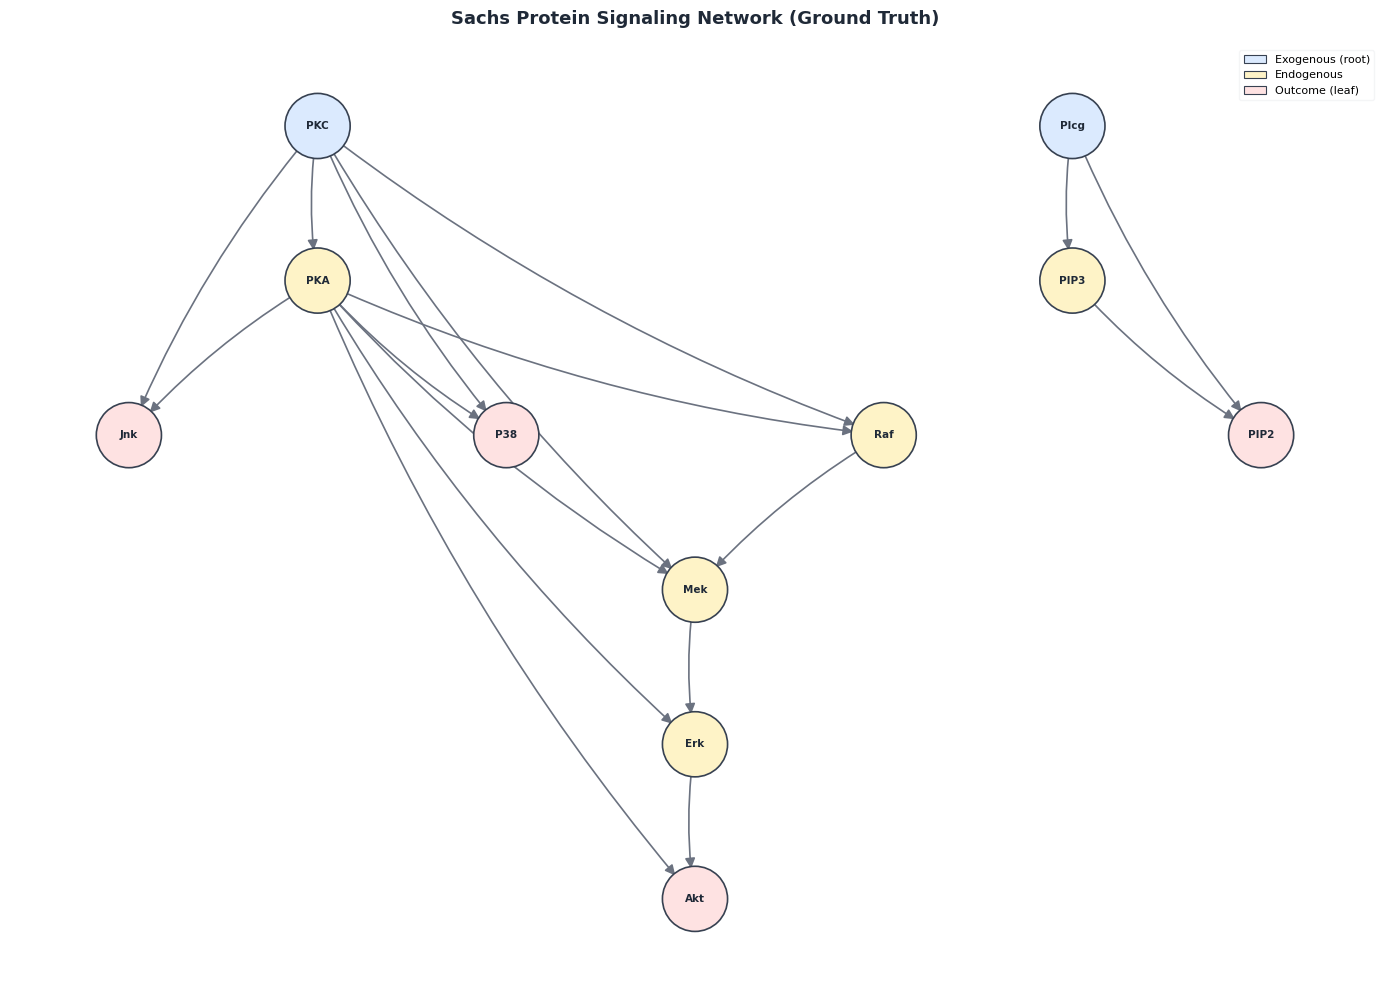

In [3]:
from causalpype import plotting

fig, ax = plotting.plot_graph(model, title="Sachs Protein Signaling Network (Ground Truth)")
plt.show()

## 3. Average Treatment Effect (ATE)

**Question:** On average, how much does activating PKC increase ERK phosphorylation across the T-cell population?

The ATE compares the expected outcome under two fixed intervention levels using the fitted structural causal model.

In [4]:
from causalpype import ATE

pkc_low  = float(df["PKC"].quantile(0.25))
pkc_high = float(df["PKC"].quantile(0.75))

ate_result = model.run(ATE(
    treatment="PKC",
    outcome="Erk",
    treatment_value=pkc_high,
    control_value=pkc_low,
    num_samples=2000,
))

ate_result.summary()

                       ATE Results                        
 Treatment                                             PKC
 Outcome                                               Erk
 Treatment Value                                    2.0000
 Control Value                                      1.0000
----------------------------------------------------------
 Estimate                                          -0.0835
 Num Samples                                         2,000


We can estimate ATEs for multiple treatment-outcome pairs and compare them visually with `plot_effects`.

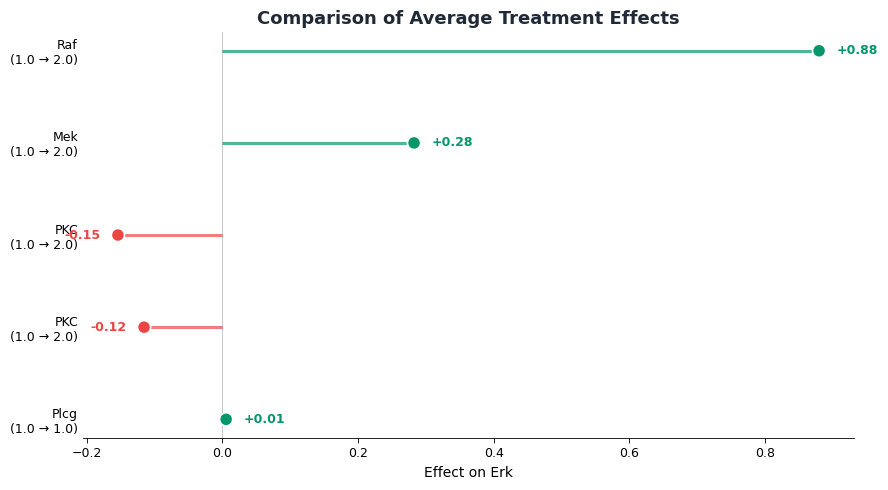

In [5]:
# Compare ATEs for several treatment→outcome pairs
ate_pairs = [
    ("PKC",  "Erk"),
    ("PKC",  "Jnk"),
    ("Raf",  "Mek"),
    ("Mek",  "Erk"),
    ("Plcg", "PIP2"),
]

ate_results = []
for t, o in ate_pairs:
    t_lo = float(df[t].quantile(0.25))
    t_hi = float(df[t].quantile(0.75))
    r = model.run(ATE(treatment=t, outcome=o, treatment_value=t_hi, control_value=t_lo))
    ate_results.append(r)

fig, ax = plotting.plot_effects(ate_results, title="Comparison of Average Treatment Effects")
plt.show()

## 4. Conditional Average Treatment Effect (CATE)

**Question:** Does the causal effect of PKC on Erk vary depending on the cell's baseline levels of other proteins?

CATE captures *heterogeneous* treatment effects. CausalPype supports multiple estimators via EconML: `linear_dml`, `causal_forest`, and `metalearner`.

                       CATE Results                       
 Treatment                                             PKC
 Outcome                                               Erk
 Effect Modifiers                           Raf, PIP3, PKA
 Method                                         linear_dml
----------------------------------------------------------
 Mean Effect                                        0.0592
 Std Effect                                         0.2625
 Bounds                                  [-0.4071, 0.5741]


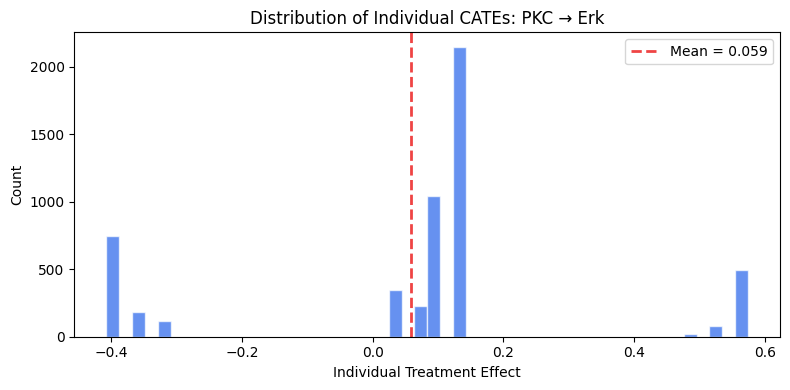

In [6]:
from causalpype import CATE

cate_result = model.run(CATE(
    treatment="PKC",
    outcome="Erk",
    effect_modifiers=["Raf", "PIP3", "PKA"],
    method="linear_dml",
))

cate_result.summary()

# Visualise the distribution of individual-level effects
effects = cate_result.details["individual_effects"].ravel()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(effects, bins=50, color="#2563EB", alpha=0.7, edgecolor="white")
ax.axvline(effects.mean(), color="#EF4444", linestyle="--", lw=2, label=f"Mean = {effects.mean():.3f}")
ax.set_xlabel("Individual Treatment Effect")
ax.set_ylabel("Count")
ax.set_title("Distribution of Individual CATEs: PKC → Erk")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Causal Effect Curve (Dose-Response)

**Question:** What is the full functional relationship between PKC activation level and downstream Erk response?

The causal effect curve sweeps the treatment across its observed range using `do(PKC = x)` and plots `E[Erk | do(PKC = x)]`.

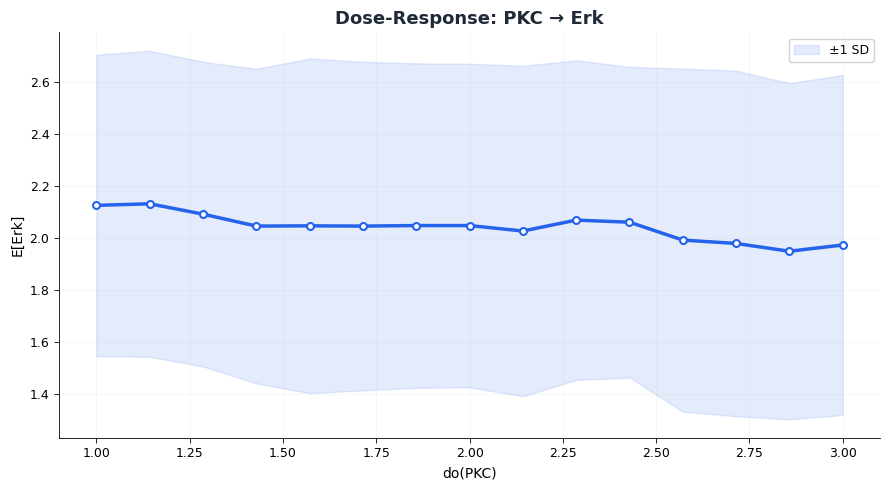

In [7]:
from causalpype import CausalEffectCurve

curve_result = model.run(CausalEffectCurve(
    treatment="PKC",
    outcome="Erk",
    n_points=15,
    num_samples=1000,
))

fig, ax = plotting.plot_causal_effect_curve(curve_result,
    title="Dose-Response: PKC → Erk")
plt.show()

## 6. KNN Matching Estimator

**Question:** Can we corroborate the PKC → Jnk effect using a non-parametric matching approach?

`KNNIntervention` matches each treated unit to its *k* nearest control neighbours (and vice versa) to estimate ATE, ATT, and ATC without parametric assumptions. Because our treatment is discrete (values 1–3) we binarise it at the median.

In [8]:
from causalpype import KNNIntervention

# Binarise PKC at the median for the matching estimator
df_bin = df.copy()
df_bin["PKC_bin"] = (df_bin["PKC"] > df_bin["PKC"].median()).astype(int)

graph_bin = graph.copy()
graph_bin.add_edge("PKC_bin", "Jnk")
model_bin = CausalModel(graph_bin, auto_assign=True, assignment_quality="better")
model_bin.fit(df_bin)

knn_result = model_bin.run(KNNIntervention(
    treatment="PKC_bin",
    outcome="Jnk",
    k=10,
    treatment_value=1,
    control_value=0,
))

knn_result.summary()

Fitting causal mechanism of node PKC_bin: 100%|██████████| 12/12 [00:00<00:00, 31.86it/s]

                 KNN Intervention Results                 
 Treatment                                         PKC_bin
 Outcome                                               Jnk
 K                                                      10
 N Treated                                             514
 N Control                                           4,886
----------------------------------------------------------
 ATE                                                0.5033
 ATT                                                0.5362
 ATC                                                0.4998
 Std ITE                                            0.5893
----------------------------------------------------------
 Match Quality (Treated)                            1.6945
 Match Quality (Control)                            3.0599


## 7. Interventional Sampling

**Question:** If we inhibit PKC (knock it down to its minimum observed level), what happens to the entire downstream signaling network?

`Intervention` draws samples from the SCM under a `do(X = x)` regime and returns the resulting joint distribution.

In [9]:
from causalpype import Intervention

pkc_knockdown = float(df["PKC"].min())

interv_result = model.run(Intervention(
    interventions={"PKC": pkc_knockdown},
    num_samples=2000,
))

interv_result.summary()

# Compare baseline vs. intervention for downstream targets
baseline = model.draw_samples(n=2000)
interv_samples = interv_result.details["samples"]

targets = ["Mek", "Erk", "Jnk", "Akt"]
fig, axes = plt.subplots(1, len(targets), figsize=(16, 4), sharey=False)
for ax, t in zip(axes, targets):
    ax.hist(baseline[t], bins=30, alpha=0.5, label="Baseline", color="#2563EB", density=True)
    ax.hist(interv_samples[t], bins=30, alpha=0.5, label="do(PKC↓)", color="#EF4444", density=True)
    ax.set_title(t, fontweight="bold")
    ax.legend(fontsize=8)
    ax.set_xlabel("Level")

fig.suptitle("Downstream effects of PKC inhibition", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

ValueError: X has 2 features, but ExtraTreesRegressor is expecting 3 features as input.

## 8. Stochastic Intervention

**Question:** What if, instead of a hard intervention, we *gently nudge* PKC levels upward?

`StochasticIntervention` adds a constant shift to the natural treatment value (for continuous variables) rather than fixing it at a single point. This models realistic partial interventions such as a low-dose drug.

In [ ]:
from causalpype import StochasticIntervention

stoch_result = model.run(StochasticIntervention(
    treatment="PKC",
    outcome="Jnk",
    shift=0.5,          # add 0.5 units to natural PKC level
    num_samples=2000,
))

stoch_result.summary()

## 9. Counterfactual Analysis

**Question:** For a *specific* T-cell that we actually observed, what would its Jnk level have been if its PKC had been maximally activated?

Counterfactual reasoning inverts the SCM noise terms for an observed individual, then re-propagates under the hypothetical intervention. This gives *individual-level* causal answers, unlike the population-level ATE.

In [ ]:
from causalpype import Counterfactual

# Pick a small subset of cells for counterfactual analysis
test_cells = df.iloc[100:105].copy()
pkc_high = float(df["PKC"].quantile(0.95))

cf_result = model.run(Counterfactual(
    interventions={"PKC": pkc_high},
    observed_data=test_cells,
    outcome="Jnk",
))

cf_result.summary()

# Show per-cell factual vs. counterfactual
cf_samples = cf_result.details["counterfactual_samples"]
comparison = pd.DataFrame({
    "Factual PKC":        test_cells["PKC"].values,
    "Factual Jnk":        test_cells["Jnk"].values,
    "CF Jnk (PKC→high)":  cf_samples["Jnk"].values,
    "Individual Effect":  cf_result.details["individual_effects"],
})
comparison.index.name = "Cell"
comparison.round(3)

## 10. Arrow Strength

**Question:** Which direct edges into Erk carry the most causal influence?

Arrow strength quantifies each parent's contribution to the target's distribution (measured by KL divergence). We also overlay the strengths on the graph.

In [ ]:
from causalpype import ArrowStrength

arrow_result = model.run(ArrowStrength(target="Erk"))
arrow_result.summary()

fig, ax = plotting.plot_arrow_strength(arrow_result,
    title="Arrow Strengths into Erk")
plt.show()

We can also overlay arrow strengths on the full network graph for all edges into a target:

In [ ]:
fig, ax = plotting.plot_graph(model, strengths=arrow_result,
    title="Sachs Network — edges coloured by strength into Erk")
plt.show()

## 11. Intrinsic Causal Influence (Variance Decomposition)

**Question:** How much of the variability in Akt is attributable to each upstream noise source?

This Shapley-value decomposition traces variance through the *entire* causal graph — unlike arrow strength, which only considers direct parents.

In [ ]:
from causalpype import IntrinsicCausalInfluence

ici_result = model.run(IntrinsicCausalInfluence(
    target="Akt",
    prediction_model="approx",
))

ici_result.summary()

fig, ax = plotting.plot_influences(ici_result,
    title="Intrinsic Causal Influence on Akt")
plt.show()

## 12. Anomaly Attribution

**Question:** When we observe T-cells with unusually high Jnk, which upstream proteins are responsible for the anomaly?

CausalPype auto-detects anomalies (top 5% by anomaly score) and attributes each outlier to its causal ancestors via Shapley values.

In [ ]:
from causalpype import AnomalyAttribution

anomaly_result = model.run(AnomalyAttribution(
    target="Jnk",
    anomaly_threshold_percentile=95,
))

anomaly_result.summary()

fig, ax = plotting.plot_anomalies(anomaly_result,
    title="Anomaly Attribution for High-Jnk Cells")
plt.show()

## 13. Distribution Change Attribution

**Question:** Suppose we observe a shift in the Erk distribution between two experimental conditions. Which upstream mechanisms are responsible?

We simulate two "conditions" by splitting the data at the PKA median (a proxy for different stimulation contexts) and ask CausalPype to attribute the distributional shift in Erk to individual nodes.

In [ ]:
from causalpype import DistributionChange

# Split data into two conditions based on PKA level
old_data = df[df["PKA"] <= df["PKA"].median()].copy()
new_data = df[df["PKA"] >  df["PKA"].median()].copy()

dc_result = model.run(DistributionChange(
    target="Erk",
    old_data=old_data,
    new_data=new_data,
    num_samples=2000,
))

dc_result.summary()

## 14. Sensitivity Analysis

**Question:** How robust is the PKC → Jnk effect estimate to potential unmeasured confounders?

CausalPype runs three refutation tests:
1. **Placebo** — permute the treatment and check whether the effect disappears.
2. **Subset** — re-estimate on random subsets to check stability.
3. **Random common cause** — inject a synthetic confounder and verify the estimate is unchanged.

In [ ]:
from causalpype import SensitivityAnalysis

pkc_lo = float(df["PKC"].quantile(0.25))
pkc_hi = float(df["PKC"].quantile(0.75))

sens_result = model.run(SensitivityAnalysis(
    treatment="PKC",
    outcome="Jnk",
    treatment_value=pkc_hi,
    control_value=pkc_lo,
    num_simulations=5,   # keep low for demo speed; increase for production
    num_samples=1000,
))

sens_result.summary()

## 15. Model Validation

CausalPype validates two aspects of the fitted causal model:

1. **Structure** — tests whether the conditional independence relations implied by the DAG hold in the data (via `refute_causal_structure`).
2. **Model** — tests whether the invertible SCM mechanisms are well-specified (via `refute_invertible_model`).

In [ ]:
validation_result = model.validate()
validation_result.summary()

## 16. Running Multiple Tasks and Generating a Report

CausalPype supports running a list of tasks in a single pipeline call and then generating a structured report.

In [ ]:
# Run several tasks at once via the pipeline
results = model.run([
    ATE(treatment="PKC", outcome="Jnk",
        treatment_value=float(df["PKC"].quantile(0.75)),
        control_value=float(df["PKC"].quantile(0.25))),
    ATE(treatment="Raf", outcome="Erk",
        treatment_value=float(df["Raf"].quantile(0.75)),
        control_value=float(df["Raf"].quantile(0.25))),
    ArrowStrength(target="Jnk"),
])

# Print each result
for r in results:
    r.summary()
    print()

In [ ]:
# Generate a structured report from the last pipeline run
print(model.report(format="text"))

In [ ]:
# The report is also available as a JSON-serialisable dict
report_dict = model.report(format="dict")
print(f"Report keys: {list(report_dict.keys())}")
print(f"Number of results: {len(report_dict['results'])}")

## Summary

This notebook demonstrated the complete CausalPype workflow on the Sachs protein signaling network:

| # | Feature | API |
|---|---|---|
| 1 | Model specification & fitting | `CausalModel(graph).fit(data)` |
| 2 | Graph visualization | `plotting.plot_graph()` |
| 3 | Average Treatment Effect | `ATE()` |
| 4 | Conditional / heterogeneous effects | `CATE()` |
| 5 | Dose-response curves | `CausalEffectCurve()` |
| 6 | Non-parametric matching | `KNNIntervention()` |
| 7 | Interventional sampling | `Intervention()` |
| 8 | Stochastic (soft) interventions | `StochasticIntervention()` |
| 9 | Counterfactual reasoning | `Counterfactual()` |
| 10 | Edge importance | `ArrowStrength()` |
| 11 | Variance decomposition | `IntrinsicCausalInfluence()` |
| 12 | Anomaly explanation | `AnomalyAttribution()` |
| 13 | Distribution shift attribution | `DistributionChange()` |
| 14 | Sensitivity / robustness | `SensitivityAnalysis()` |
| 15 | Model validation | `model.validate()` |
| 16 | Pipeline & reporting | `model.run([...])`, `model.report()` |

### References

- Sachs K, Perez O, Pe'er D, Lauffenburger DA, Nolan GP. *Causal protein-signaling networks derived from multiparameter single-cell data.* Science. 2005;308(5721):523-529.
- Pearl J. *Causality: Models, Reasoning and Inference.* Cambridge University Press, 2009.
- Blöbaum P, Götz P, Budhathoki K, Mastakouri A, Janzing D. *DoWhy-GCM: An extension of DoWhy for causal inference in graphical causal models.* JMLR, 2024.